## Today's topics

- What is p-value and Confidence Interval, Critical Value
- Hypothesis Testing - Type I and Type II errors

---


## 1️⃣ What is p-value?

p-value tells us how extreme our sample result is assuming the Null Hypothesis (H₀) is true.

	•	Small p-value → data is unlikely under H₀
	•	Large p-value → data is likely under H₀

Claim:

Average marks = 60

We collect sample data and check how far the sample mean is from 60.


In [ ]:
import numpy as np
import math

data = np.array([52, 55, 58, 60, 62, 65, 67, 68, 70, 72])
n = len(data)

n

10

In [ ]:
sample_mean = data.sum() / n
sample_mean

np.float64(62.9)

In [ ]:
sample_variance = ((data - sample_mean) ** 2).sum() / (n - 1)
sample_std = sample_variance ** 0.5

sample_std

np.float64(6.624030327359453)

In [ ]:
SE = sample_std / math.sqrt(n)
SE

np.float64(2.0947023124486632)

Test Statistic (Z-score)

In [ ]:
mu_0 = 60  # Null hypothesis mean

z_score = (sample_mean - mu_0) / SE
z_score

np.float64(1.384444931752598)

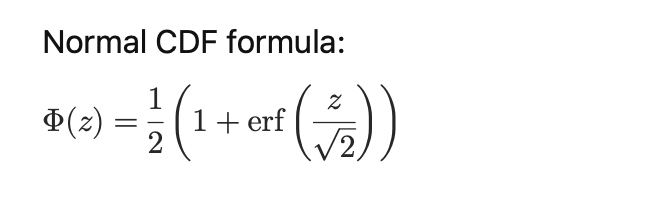

In [ ]:
def normal_cdf(z):
    return 0.5 * (1 + math.erf(z / math.sqrt(2)))

In [ ]:
p_value_one_tailed = 1 - normal_cdf(abs(z_score))
p_value_one_tailed

0.08311112946354604

In [ ]:
p_value_two_tailed = 2 * (1 - normal_cdf(abs(z_score)))
p_value_two_tailed

0.16622225892709208

In [ ]:
# Compare with Significance Level

alpha = 0.05

if p_value_two_tailed < alpha:
    decision = "Reject Null Hypothesis (H0)"
else:
    decision = "Fail to Reject Null Hypothesis (H0)"

decision

'Fail to Reject Null Hypothesis (H0)'


## 2️⃣ Confidence Interval

A confidence interval provides a range  
within which the true population parameter is likely to lie.


In [ ]:
import numpy as np
import math

# Sample data (e.g., marks / heights / salaries)
data = np.array([52, 55, 58, 60, 62, 65, 67, 68, 70, 72])

n = len(data)
n

10

In [ ]:
mean = data.sum() / n
mean

np.float64(62.9)

In [ ]:
variance = ((data - mean) ** 2).sum() / (n - 1)
std = variance ** 0.5

std

np.float64(6.624030327359453)

In [ ]:
SE = std / math.sqrt(n)
SE

np.float64(2.0947023124486632)

In [ ]:
# Choose Confidence Level & Critical Value

confidence_level = 0.95
z_critical = 1.96   # for 95% confidence (two-sided)

confidence_level, z_critical

(0.95, 1.96)

In [ ]:
# Compute Confidence Interval

lower_ci = mean - z_critical * SE
upper_ci = mean + z_critical * SE

(lower_ci, upper_ci)

(np.float64(58.79438346760062), np.float64(67.00561653239937))

In [ ]:
f"We are 95% confident that the true population mean lies between {lower_ci:.2f} and {upper_ci:.2f}"

'We are 95% confident that the true population mean lies between 58.79 and 67.01'

In [ ]:
mu_0 = 60  # hypothesized mean

if lower_ci <= mu_0 <= upper_ci:
    ci_support = "Hypothesized mean is INSIDE the confidence interval"
else:
    ci_support = "Hypothesized mean is OUTSIDE the confidence interval"

ci_support

'Hypothesized mean is INSIDE the confidence interval'


## 3️⃣ Critical Value

Critical value is the threshold  
used to decide whether to reject H₀.

"Critical value can find either using **standard statistical tables** or using **python libraries**."


In [ ]:
from scipy.stats import norm

alpha = 0.05   # 5% significance level
alpha

0.05

In [ ]:
# Z Critical Value (Two-Tailed Test)

z_critical = norm.ppf(1 - alpha/2)
z_critical

np.float64(1.959963984540054)

In [ ]:
# One-Tailed Z Critical Value

# Right-tailed
z_right = norm.ppf(1 - alpha)
z_right

np.float64(1.6448536269514722)

In [ ]:
# Left-tailed
z_left = norm.ppf(alpha)
z_left

np.float64(-1.6448536269514729)

**t-Critical Value using Libraries**

Used when:

	•	Sample size < 30
	•	Population std unknown

In [ ]:
from scipy.stats import t

n = 10

# Degree of Freedom
df = n - 1
df

9

In [ ]:
# Two-Tailed t Critical Value

t_critical = t.ppf(1 - alpha/2, df)
t_critical

np.float64(2.2621571628540993)

In [ ]:
# One-Tailed t Critical Value

t_right = t.ppf(1 - alpha, df)
t_left = t.ppf(alpha, df)

t_right, t_left

(np.float64(1.8331129326536335), np.float64(-1.8331129326536337))

In [ ]:
test_statistic = 2.3

if abs(test_statistic) > z_critical:
    decision = "Reject Null Hypothesis (H0)"
else:
    decision = "Fail to Reject Null Hypothesis (H0)"

decision

'Reject Null Hypothesis (H0)'

#### Critical value = quantile (ppf) of the distribution


## 4️⃣ Type I and Type II Errors

- Type I Error → Rejecting true H₀ (False Positive)  
- Type II Error → Failing to reject false H₀ (False Negative)



📘 First: What are we testing?

👉 Suppose we test this claim:

**H₀ (Null Hypothesis):** Average marks = 60

**H₁ (Alternative Hypothesis):** Average marks ≠ 60

#### **🔴 Type-I Error (False Positive)**

📌 Meaning

Rejecting H₀ when H₀ is actually TRUE

📘 Real-life meaning:

	•	Alarm rings ❌ but there is no fire
	•	Student is marked cheating ❌ but is innocent

In [ ]:
# Just Simulation based code

# Reality
H0_true = True   # Null hypothesis is actually true

# Our decision
decision = "Reject H0"   # We rejected it

# Check error type
if H0_true and decision == "Reject H0":
    error_type = "Type-I Error"
else:
    error_type = "No Type-I Error"

error_type

'Type-I Error'

"**Type-I Error** happened because **we rejected a TRUE null hypothesis.**"

#### **🔵 Type-II Error (False Negative)**

📌 Meaning

Failing to reject H₀ when H₀ is actually FALSE

📘 Real-life meaning:

	•	Fire exists 🔥 but alarm does not ring
	•	Disease exists but test says no disease

In [ ]:
# Just Simulation based code

# Reality
H0_false = True   # Null hypothesis is actually false

# Our decision
decision = "Fail to Reject H0"

# Check error type
if H0_false and decision == "Fail to Reject H0":
    error_type = "Type-II Error"
else:
    error_type = "No Type-II Error"

error_type

'Type-II Error'

"**Type-II Error** happened because **we accepted a FALSE null hypothesis.**"


## 📝 Practice Questions
1. Explain p-value in simple words.
2. Difference between CI and p-value.
3. Explain Type I & Type II errors.



## 📌 Mini Assignment

Claim: Average service time is 5 minutes.
- Assume sample data
- Calculate p-value and CI
- Identify possible errors
